# Conditional Retrieval with LangGraph: Building Intelligent, Adaptive RAG Agents

Welcome to advanced retrieval-augmented generation (RAG). While basic RAG pipelines simply retrieve and generate regardless of the query, real-world applications require intelligence—the ability to decide *if* they need external information at all. This notebook introduces **Conditional Retrieval**, a critical pattern for building robust, production-grade AI agents. We use LangGraph to implement a sophisticated routing mechanism that acts as an intelligent gatekeeper: before answering any question, the agent first classifies whether the query requires specialized document knowledge or if it can be answered using general world knowledge.

This approach solves two major problems in RAG: 1) **Over-reliance:** Preventing the model from hallucinating when no documents are provided, and 2) **Under-utilization:** Ensuring that the system doesn't waste time retrieving irrelevant context for simple questions (e.g., "What is the capital of France?"). By structuring our workflow with LangGraph, we define a state machine where the flow dynamically adapts based on the query's nature. The agent moves through distinct nodes—classification, retrieval, and generation—only executing the necessary steps to produce the most accurate and contextually appropriate answer.

By mastering this pattern, you move beyond simple chaining and into true **agentic design**. You learn how to use structured output (Pydantic) for reliable decision-making and how to manage complex, multi-step workflows using LangGraph's conditional edges. This skill is foundational for building any advanced AI system that needs to adapt its internal logic based on user input, making your RAG application significantly more robust and trustworthy.

***

### Learning Objectives

Upon completing this notebook, you will be able to:

*   **Implement Advanced State Management:** Define a complex `StateGraph` using LangGraph to manage the flow of data (query, context, documents) across multiple processing steps.
*   **Master Conditional Routing:** Utilize conditional edges (`add_conditional_edges`) to build decision-making logic that dynamically routes execution paths based on an LLM's classification output.
*   **Design Intelligent Agents:** Build a multi-stage agentic workflow that first classifies the intent of a query (e.g., "Does this need documents?") before proceeding with retrieval or generation.
*   **Use Structured Output for Logic:** Leverage Pydantic models and `with_structured_output` to force an LLM to output reliable, machine-readable decisions (like a boolean flag) that drive the graph's flow.
*   **Optimize RAG Performance:** Understand how conditional logic improves both accuracy and efficiency by preventing unnecessary document retrieval when general knowledge is sufficient.


### Setup and Imports

This cell initializes the environment by loading API keys from a `.env` file. It then imports all necessary libraries, including tools for defining structured data (`pydantic`), building prompts (`ChatPromptTemplate`), handling document loading/splitting (PDFs), interacting with OpenAI models/embeddings, managing vector storage (`Chroma`), and setting up the core graph structure using `langgraph`.


In [2]:
# Section 1 — Setup and Imports
from dotenv import load_dotenv
# Load environment variables (like API keys) from a .env file
load_dotenv()

from typing import Literal
# Used for defining literal types in Pydantic/typing
from pydantic import BaseModel
# Used to define the structure of inputs/outputs for models
from langchain_core.prompts import ChatPromptTemplate
# Core class for creating structured prompts
from langchain_community.document_loaders import PyPDFLoader
# Loader specifically for PDF files
from langchain_text_splitters import RecursiveCharacterTextSplitter
# Tool to split large documents into smaller, manageable chunks
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# Imports the chat model and embedding function from OpenAI
from langchain_chroma import Chroma
# Integration with ChromaDB for vector storage
from langchain_core.documents import Document
# Standard LangChain document representation
from langgraph.graph import StateGraph, START, END, MessagesState
# Core components for building the state machine graph


### Document Loading

This cell initializes and executes a document loader using `PyPDFLoader` to read content from the specified PDF file. The loaded documents are stored in the `raw_docs` variable, which is crucial for subsequent embedding and retrieval steps.


In [3]:
# Section 2 — Document Loading
# Initialize the PyPDFLoader with the path to the target document.
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
# Load all pages from the PDF into a list of LangChain Document objects.
raw_docs = loader.load()

# Print confirmation and count of loaded documents (pages).
print(f"Loaded {len(raw_docs)} pages")


Loaded 15 pages


### Text Chunking (Splitting Documents)

This step uses `RecursiveCharacterTextSplitter` to break down large documents (`raw_docs`) into smaller, manageable pieces called 'chunks'. This is crucial for RAG because embedding models have token limits and retrieving small chunks improves the precision of the context provided to the LLM.


In [4]:
# Section 3 — Text Chunking
# Initialize the splitter with specified chunk size (900 tokens) and overlap (150 tokens).
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
# Split the raw documents into a list of smaller document chunks.
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")


Split into 51 chunks


### Embedding Model Initialization

This cell initializes the embedding model, which is crucial for converting text (like documents or queries) into high-dimensional numerical vectors. The `OpenAIEmbeddings` class handles this process using OpenAI's efficient `text-embedding-3-small` model.


In [5]:
# Section 4 — Embedding Model
# Initialize the embedding model using the specified OpenAI class.
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


### Vector Store Initialization and Indexing

This cell initializes a Chroma vector store, ensuring that the provided `chunks` (document chunks) are embedded and indexed into the specified collection (`rag_conditional`). This step is crucial because it transforms raw text data into numerical vectors, making them searchable for retrieval-augmented generation (RAG).


In [6]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

# Add the document chunks to the vector store. This process embeds and indexes the data.
vectorstore.add_documents(documents=chunks)

# Create a retriever object from the populated vector store, specifying that it should retrieve the top 4 results (k=4).
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")


Vector store ready


### LLM Initialization

This cell initializes the Language Model (LLM) used throughout the notebook. We use `ChatOpenAI` from LangChain, specifying a model name (`gpt-5-mini`) to ensure all subsequent interactions and reasoning steps are powered by a powerful conversational AI.


In [7]:
# Section 6 — LLM
# Initialize the ChatOpenAI object, which represents the Language Model.
llm = ChatOpenAI(model="gpt-5-mini")


### State Definition for Agentic RAG

This class, `AgenticRAGState`, defines the structured state that will be passed and updated throughout the LangGraph workflow. It inherits from `MessagesState` (likely a base state container) and explicitly tracks key pieces of information: the original query, retrieved documents, synthesized context, final generation output, and a boolean flag (`needs_retrieval`) to guide conditional routing.


In [8]:
# Section 7 — State Definition
class AgenticRAGState(MessagesState):
    # Defines the structured state for the agentic RAG process.
    query: str                 # Stores the initial user query.
    retrieved_docs: list[Document] | None # Holds documents retrieved from the vector store.
    context: str               # The synthesized context derived from the retrieved documents.
    generation: str            # Placeholder for the final generated answer.
    needs_retrieval: bool      # A boolean flag used by LangGraph to determine if retrieval is necessary.


### Code Explanation

This cell defines a structured output schema using Pydantic's `BaseModel`. It is crucial for enforcing that the LLM's routing decision (whether retrieval is needed) adheres to a predictable, machine-readable format (`needs_retrieval: bool`), which allows the LangGraph workflow to conditionally proceed.


In [9]:
# structured output schema for the routing decision
class RouteDecision(BaseModel):
    
    needs_retrieval: bool


### Conditional Retrieval Router

This function acts as a router node, determining if the incoming user query requires external document retrieval. It uses an LLM with structured output to classify the query's intent (i.e., whether it needs specialized documents or general knowledge), ensuring that expensive retrieval steps are only executed when necessary.


In [10]:
# route_question node — classifies whether the query needs document retrieval
def route_question(state: AgenticRAGState) -> dict:
    
    # Define the prompt template for classification
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    
    # Create a chain that uses the prompt and forces structured output (RouteDecision)
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    
    # Invoke the chain using the query from the state, getting a structured decision object
    decision = chain.invoke({"query": state["query"]})
    
    # Return the classification result to guide the next step in the graph
    return {"needs_retrieval": decision.needs_retrieval}


### Retrieval Node Function

This function, `retrieve`, acts as a dedicated node in the LangGraph workflow. It takes the current state (containing the user's query) and uses the initialized `retriever` to fetch relevant documents from the vector store. The retrieved documents are then formatted into a single context string for subsequent steps.


In [11]:
# retrieve node — fetches relevant documents from the vector store
def retrieve(state: AgenticRAGState) -> dict:
    
    # Use the retriever to fetch documents based on the query stored in the state.
    docs = retriever.invoke(state["query"])
    
    # Check if any documents were successfully retrieved.
    if docs:
        # If documents exist, join their page content into a single context string.
        context = "\n\n".join(doc.page_content for doc in docs)

    # Return the list of raw document objects and the formatted context string to update the state.
    return {"retrieved_docs": docs, "context": context}


This `generate` node function is the final step in the RAG chain. It conditionally generates an answer: if context was retrieved, it uses a system prompt forcing the LLM to rely *only* on that context; otherwise, it allows the LLM to use its general knowledge.


In [12]:
# generate node — produces the final answer, with or without retrieved context
def generate(state: AgenticRAGState) -> dict:
    
    query = state["query"]
    context = state.get("context") or "" # Safely retrieve context, defaulting to empty string if missing


    if context:    # Check if any context was successfully retrieved
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"), # System prompt enforces grounding in provided context
            ("human", "{query}"),
        ])
        
        # Invoke the LLM with both context and query, forcing grounded response
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    
    else: # If no context was retrieved (e.g., general knowledge question)
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."), # System prompt allows general knowledge use
            ("human", "{query}"),
        ])
        
        # Invoke the LLM using only the query
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content} # Return the generated answer content in the state dictionary



### Conditional Routing Function

This function acts as a router within the LangGraph state machine. It inspects the `needs_retrieval` boolean flag stored in the agent's state and conditionally directs the workflow to either the `retrieve` node (if external knowledge is needed) or directly to the `generate` node (if the answer can be formulated without retrieval).


In [19]:
# routing function: maps needs_retrieval bool to the next node name
# The function takes the current state of the agentic RAG process.
def route_after_classification(state: AgenticRAGState) -> Literal["retrieve", "generate"]:
    # Check the boolean flag 'needs_retrieval' in the state dictionary.
    # If True, it means the classification step determined that retrieval is necessary.
    return "retrieve" if state["needs_retrieval"] else "generate"


### Graph Definition and Flow Control

This cell defines the structure of the agentic workflow using `StateGraph`. It establishes nodes for initial routing, retrieval, and generation. The key feature is the conditional edge from `needs_retrieval`, which determines whether to proceed directly or perform a knowledge retrieval step.


In [20]:
# Graph Definition
graph_builder = StateGraph(AgenticRAGState)

# Define the nodes (steps) in the graph
graph_builder.add_node("needs_retrieval", route_question)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

# Define the initial entry point and flow
graph_builder.add_edge(START, "needs_retrieval") # Start always goes to the routing node

# Add conditional logic: after 'needs_retrieval', decide next step (retrieve or skip)
graph_builder.add_conditional_edges("needs_retrieval", route_after_classification)

# Define sequential flow from retrieval to generation
graph_builder.add_edge("retrieve", "generate")

# Define the final step, leading to the end of the graph
graph_builder.add_edge("generate", END)


### Graph Compilation

This line compiles the defined LangGraph workflow (`graph_builder`) into a runnable state machine object. The resulting `graph` object is an executable graph that can be invoked with input data, managing the flow between nodes and edges.


In [21]:
graph = graph_builder.compile()


This cell executes the defined LangGraph object (`graph`), which is typically used to compile and visualize the state machine or run a test instance of the graph. It confirms that the graph structure has been correctly initialized and can be executed.


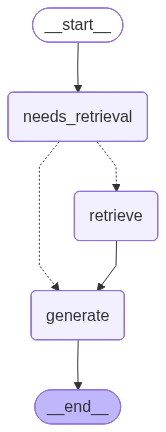

In [22]:
graph # Executes the compiled LangGraph object, allowing for visualization or testing of the defined workflow.


### Code Explanation

This cell executes the LangGraph workflow (`graph.invoke`) using a domain-specific query. This is crucial for testing the conditional retrieval logic, as the specialized nature of the query should trigger the graph's internal mechanism to perform and utilize document retrieval.


In [23]:
# Query 1: domain-specific (should trigger retrieval)
domain_query = "What does the report say about EV adoption trajectories and oil demand displacement?"

# Invoke the LangGraph workflow with the domain query. 
# The graph processes this query, potentially triggering a retriever step.
result_domain = graph.invoke({"query": domain_query, "messages": []})


### Code Explanation

This cell is used for inspecting and visualizing the output of a single, domain-specific query. It prints the original query, whether retrieval was deemed necessary (`needs_retrieval`), the count of retrieved documents, and finally, the generated answer, allowing for easy debugging and verification of the RAG pipeline's performance.


In [24]:
# Output: Query 1 (domain-specific)
print("=== QUERY 1 (domain-specific) ===")
print(f"Query          : {domain_query}")
print(f"needs_retrieval: {result_domain['needs_retrieval']}")
retrieved = result_domain.get("retrieved_docs") or [] # Safely retrieves the list of documents, defaulting to an empty list if missing.
print(f"Retrieved docs : {len(retrieved)} docs")
print(f"\nGeneration:\n{result_domain['generation']}")


=== QUERY 1 (domain-specific) ===
Query          : What does the report say about EV adoption trajectories and oil demand displacement?
needs_retrieval: True
Retrieved docs : 4 docs

Generation:
- The report says projecting oil demand displacement from EVs requires integrating three layers: annual new‑EV sales trajectories, retirement rates of the existing ICE fleet, and the mileage/fuel‑economy of the vehicles being displaced.

- The global passenger vehicle stock is about 1.4 billion (mostly ICE). With ~90 million new vehicle sales per year and 15–20 year vehicle lifetimes in developed markets (often longer in developing markets), full fleet electrification cannot happen quickly — it is constrained by turnover.

- Major forecasters (IEA, BloombergNEF, McKinsey) project EVs will make up roughly 40–60% of new vehicle sales by 2030. The EV stock is expected to grow from ~40 million today to about 300–500 million by the early 2030s.

- The report’s scope is passenger and light commercial

### Section 9 — Query 2: General Knowledge (Skipping Retrieval)

This cell demonstrates how the RAG graph handles queries that do not require external knowledge. By invoking the graph with a general query, we test the conditional logic to ensure the retrieval step is correctly bypassed, allowing the LLM to answer based solely on its internal knowledge.


In [25]:
# Section 9 — Query 2: general knowledge (should skip retrieval)
# Define a general knowledge query that does not require document lookup.
general_query = "What is the capital of India?"

# Invoke the graph with the general query. The conditional logic within the graph
# should detect that no relevant documents are needed and proceed directly to generation.
result_general = graph.invoke({"query": general_query, "messages": []})


### Code Explanation

This cell demonstrates the final output and results for a general knowledge query (Query 2). It prints the original query, whether retrieval was deemed necessary by the conditional logic (`needs_retrieval`), any documents retrieved, and finally, the generated answer based on the entire process.


In [26]:
# Output: Query 2 (general knowledge)
print("=== QUERY 2 (general knowledge) ===")
# Print the original query used for this test case.
print(f"Query          : {general_query}")
# Display the boolean result from the conditional retrieval logic.
print(f"needs_retrieval: {result_general['needs_retrieval']}")
# Display the list of documents retrieved (or None/empty if not needed).
print(f"Retrieved docs : {result_general.get('retrieved_docs')}")
# Print a separator and then display the final generated answer.
print(f"\nGeneration:\n{result_general['generation']}")


=== QUERY 2 (general knowledge) ===
Query          : What is the capital of India?
needs_retrieval: False
Retrieved docs : None

Generation:
The capital of India is New Delhi.
